In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [ ]:

# 1. Load dataset
df = pd.read_csv("/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head())
print(df.shape)
print(df.info())



   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
# 2. Drop useless columns
df = df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1)


# 3. Convert target column
df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})


# 4. One-hot encode categorical columns
#df = pd.get_dummies(df, drop_first=True)


categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [ ]:

# 5. Separate input and output
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


In [ ]:


# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 7. Create Decision Tree model with good parameters
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10, #defines the minimum number of samples required to be at a leaf node
    class_weight="balanced",
    random_state=42
)
'''
min_samples_split specifies the minimum number of samples a node
must have to be split into two child nodes.

min_samples_leaf specifies the minimum number of samples
required to be at a leaf node

Setting class_weight='balanced' automatically handles imbalanced datasets
by assigning higher weights to minority classes and lower weights to majority classes.

When to use it:
You have an imbalanced dataset, and the model is biased toward the
majority class.
'''


# 8. Train model
model.fit(X_train, y_train)


# 9. Prediction
y_pred = model.predict(X_test)


# 10. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.7278911564625851

Confusion Matrix:
[[191  56]
 [ 24  23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       247
           1       0.29      0.49      0.37        47

    accuracy                           0.73       294
   macro avg       0.59      0.63      0.60       294
weighted avg       0.79      0.73      0.75       294




Top 15 Important Features:
                       Feature  Importance
16           TotalWorkingYears    0.264985
43                OverTime_Yes    0.209890
0                          Age    0.115956
9                MonthlyIncome    0.088659
11          NumCompaniesWorked    0.087449
4      EnvironmentSatisfaction    0.085303
18             WorkLifeBalance    0.042918
2             DistanceFromHome    0.035799
38  JobRole_Research Scientist    0.034691
1                    DailyRate    0.021532
5                   HourlyRate    0.012818
3                    Education    0.000000
10                 MonthlyRate    0.000000
8              JobSatisfaction    0.000000
6               JobInvolvement    0.000000


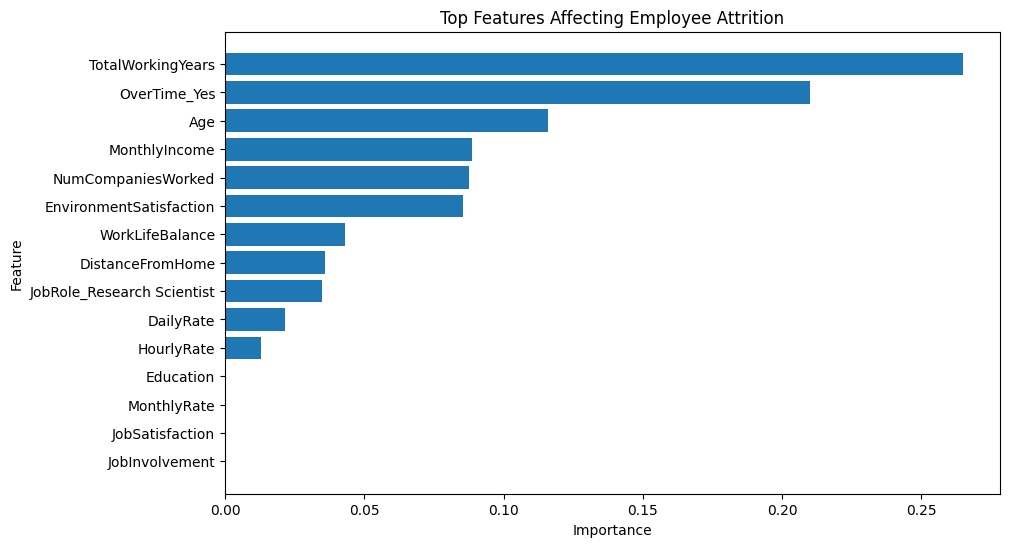

In [ ]:

# 11. Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance.head(15))


# 12. Plot feature importance
top_features = importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Affecting Employee Attrition")
plt.gca().invert_yaxis()
plt.show()



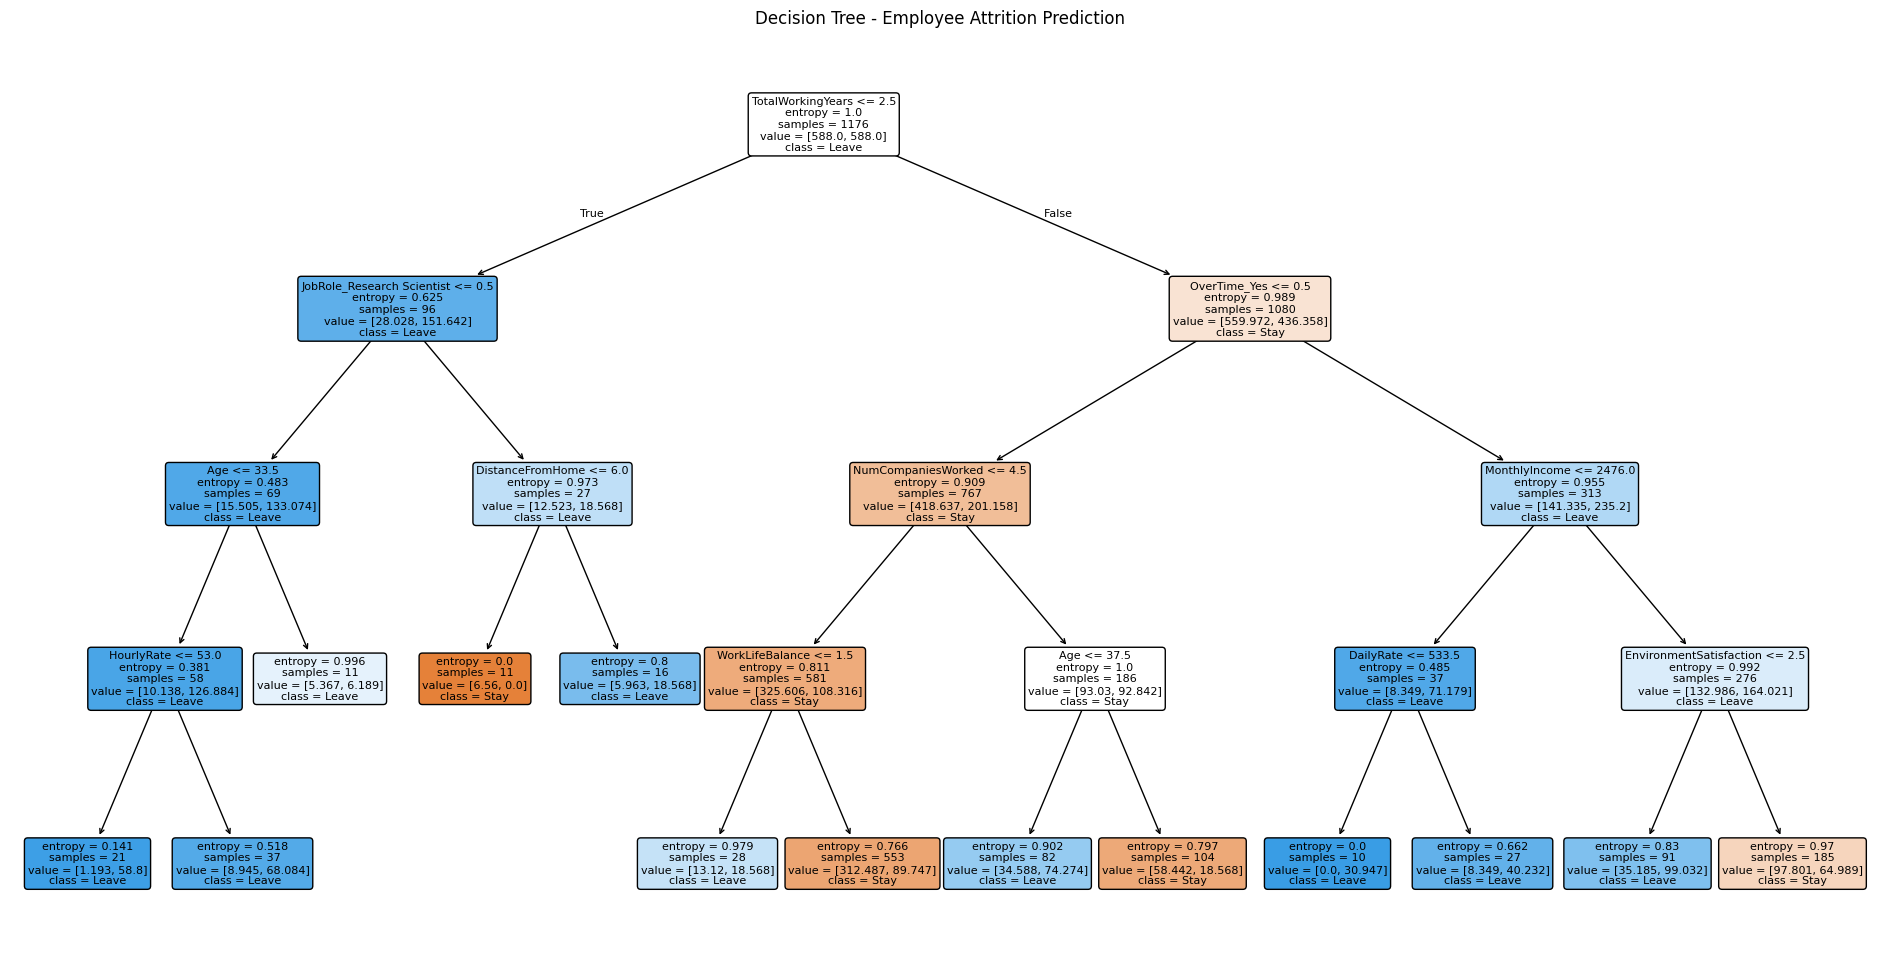

In [ ]:

# 13. Visualize Decision Tree
plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Stay", "Leave"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Employee Attrition Prediction")
plt.show()